# Data Preparation

In [1]:
# Libraries
import xarray as xr
import numpy as np

In [2]:
data =  xr.open_dataset(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/Ind_SPEI1_ERA5_monthly_5class.nc')
data

<xarray.Dataset> Size: 498MB
Dimensions:      (time: 1020, lat: 116, lon: 117)
Coordinates:
  * time         (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2024-12-01
  * lat          (lat) float64 928B 37.0 36.75 36.5 36.25 ... 9.0 8.75 8.5 8.25
  * lon          (lon) float64 936B 68.25 68.5 68.75 69.0 ... 96.75 97.0 97.25
Data variables:
    SPEI1        (time, lat, lon) float64 111MB ...
    t2m          (time, lat, lon) float32 55MB ...
    e            (time, lat, lon) float32 55MB ...
    ro           (time, lat, lon) float32 55MB ...
    tp           (time, lat, lon) float32 55MB ...
    cdir         (time, lat, lon) float32 55MB ...
    SPEI1_class  (time, lat, lon) float64 111MB ...
Attributes: (12/17)
    title:                   SPEI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 13/08/2024 12:16:55 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    cds_data_catalogue_url:  https://ecds.ecmwf.int/datasets/derived-drought-...

## z-score normalization

In [3]:
def create_train_valid_test_dataset_meanstd(
    ds,
    predictor_vars,
    target_var='SPEI1_class',
    lead_steps=0,
    train_years=slice("1940-01-01", "2000-12-31"),
    valid_years=slice("2000-01-01", "2020-12-31"),
    test_years=slice("2021-01-01", "2024-12-31"),
    eps=1e-6,
):
    """
    Create train/valid/test datasets with Mean–Std normalization for predictors.
    Target variable (categorical) is not normalized.

    Returns:
        X_train, Y_train, X_valid, Y_valid, X_test, Y_test, norm_stats, time_train, time_valid, time_test
        where time_* are the time indices corresponding to Y_*
    """

    # --------------------------------------------------
    # 1. Split datasets
    # --------------------------------------------------
    train_ds = ds.sel(time=train_years)
    valid_ds = ds.sel(time=valid_years)
    test_ds  = ds.sel(time=test_years)

    # --------------------------------------------------
    # 2. Compute Mean–Std for predictors (TRAIN ONLY)
    # --------------------------------------------------
    X_train_arr = train_ds[predictor_vars].to_array(dim="variable")

    predictor_mean = X_train_arr.mean(
        dim=["time", "lat", "lon"]
    ).values

    predictor_std = X_train_arr.std(
        dim=["time", "lat", "lon"]
    ).values

    predictor_std = np.maximum(predictor_std, eps)

    # --------------------------------------------------
    # 3. Normalize predictors
    # --------------------------------------------------
    def normalize_predictors(ds_in):
        arr = ds_in[predictor_vars].to_array(dim="variable")
        arr_norm = (
            arr - predictor_mean[:, None, None, None]
        ) / predictor_std[:, None, None, None]
        return arr_norm

    X_train_norm = normalize_predictors(train_ds)
    X_valid_norm = normalize_predictors(valid_ds)
    X_test_norm  = normalize_predictors(test_ds)

    # --------------------------------------------------
    # 4. Target variable (categorical - no normalization)
    # --------------------------------------------------
    def get_target(ds_in):
        return ds_in[target_var]

    Y_train = get_target(train_ds)
    Y_valid = get_target(valid_ds)
    Y_test  = get_target(test_ds)

    # --------------------------------------------------
    # 5. Create X–Y pairs with lead time
    # --------------------------------------------------
    def create_XY(X_norm, Y_data):
        X = (
            X_norm.isel(time=slice(None, None if lead_steps == 0 else -lead_steps))
            .transpose("time", "variable", "lat", "lon")
            .values
        )

        Y = (
            Y_data.isel(time=slice(lead_steps, None))
            .expand_dims(dim="variable", axis=1)
            .transpose("time", "variable", "lat", "lon")
            .values
        )

        return X, Y

    X_train, Y_train = create_XY(X_train_norm, Y_train)
    X_valid, Y_valid = create_XY(X_valid_norm, Y_valid)
    X_test,  Y_test  = create_XY(X_test_norm,  Y_test)

    # --------------------------------------------------
    # 6. Get time indices for Y
    # --------------------------------------------------
    time_train = train_ds.time.isel(time=slice(lead_steps, None)).values
    time_valid = valid_ds.time.isel(time=slice(lead_steps, None)).values
    time_test = test_ds.time.isel(time=slice(lead_steps, None)).values

    # --------------------------------------------------
    # 7. Store normalization stats (predictors only)
    # --------------------------------------------------
    norm_stats = {
        "predictor_mean": predictor_mean,
        "predictor_std": predictor_std,
    }

    return X_train, Y_train, X_valid, Y_valid, X_test, Y_test, norm_stats, time_train, time_valid, time_test

In [4]:
# -----------------------------
# 1. Define predictors and target
# -----------------------------
predictor_vars = [
    "t2m", "e", 'ro', 'tp','cdir'
  # autoregressive input 
]
# predictor_vars = ["TMP_2m"]
# Single continuous target
target_var = "SPEI1_class"

lead_steps = 0  # predict 1 time step ahead

# -----------------------------
# 2. Create train/valid/test datasets
# -----------------------------
X_train, Y_train, X_valid, Y_valid, X_test, Y_test, norm_stats, time_train, time_valid, time_test = \
    create_train_valid_test_dataset_meanstd(
        ds=data,
        predictor_vars=predictor_vars,
        target_var=target_var,
        lead_steps=lead_steps
    )

# -----------------------------
# 3. Quick sanity check
# -----------------------------
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_valid shape:", X_valid.shape)
print("Y_valid shape:", Y_valid.shape)
print("Predictor channels:", len(predictor_vars))


X_train shape: (732, 5, 116, 117)
Y_train shape: (732, 1, 116, 117)
X_valid shape: (252, 5, 116, 117)
Y_valid shape: (252, 1, 116, 117)
Predictor channels: 5


In [3]:
def create_train_valid_test_dataset_meanstd(
    ds,
    predictor_vars,
    target_var='SPEI1_class',
    lead_steps=0,
    lag=0,
    train_years=slice("1940-01-01", "2000-12-31"),
    valid_years=slice("2000-01-01", "2020-12-31"),
    test_years=slice("2021-01-01", "2024-12-31"),
    eps=1e-6,
):
    """
    Create train/valid/test datasets with Mean-Std normalization for predictors.
    Target variable (categorical) is not normalized.

    Parameters:
    -----------
    lag : int
        Number of past months to include as additional channels.
        If lag=2, for each time step t, the input will contain
        data from [t-2, t-1, t], stacked along the channel (variable) dimension.
        The first `lag` time steps are dropped since full lag history is unavailable.

    Returns:
        X_train, Y_train, X_valid, Y_valid, X_test, Y_test, norm_stats, time_train, time_valid, time_test
        where time_* are the time indices corresponding to Y_*
    """
    # --------------------------------------------------
    # 1. Split datasets
    # --------------------------------------------------
    train_ds = ds.sel(time=train_years)
    valid_ds = ds.sel(time=valid_years)
    test_ds  = ds.sel(time=test_years)

    # --------------------------------------------------
    # 2. Compute Mean-Std for predictors (TRAIN ONLY)
    # --------------------------------------------------
    X_train_arr = train_ds[predictor_vars].to_array(dim="variable")
    predictor_mean = X_train_arr.mean(
        dim=["time", "lat", "lon"]
    ).values
    predictor_std = X_train_arr.std(
        dim=["time", "lat", "lon"]
    ).values
    predictor_std = np.maximum(predictor_std, eps)

    # --------------------------------------------------
    # 3. Normalize predictors
    # --------------------------------------------------
    def normalize_predictors(ds_in):
        arr = ds_in[predictor_vars].to_array(dim="variable")
        arr_norm = (
            arr - predictor_mean[:, None, None, None]
        ) / predictor_std[:, None, None, None]
        return arr_norm  # shape: (variable, time, lat, lon)

    X_train_norm = normalize_predictors(train_ds)
    X_valid_norm = normalize_predictors(valid_ds)
    X_test_norm  = normalize_predictors(test_ds)

    # --------------------------------------------------
    # 4. Target variable (categorical - no normalization)
    # --------------------------------------------------
    def get_target(ds_in):
        return ds_in[target_var]

    Y_train = get_target(train_ds)
    Y_valid = get_target(valid_ds)
    Y_test  = get_target(test_ds)

    # --------------------------------------------------
    # 5. Build lagged X array
    #    For lag=L and time index t, stack:
    #    [X(t-L), X(t-L+1), ..., X(t-1), X(t)]
    #    along the channel (variable) dimension.
    #    Shape: (n_vars * (lag+1), time, lat, lon) → transposed to
    #           (time, n_vars*(lag+1), lat, lon)
    # --------------------------------------------------
    def create_lagged_X(X_norm):
        """
        X_norm shape: (variable, time, lat, lon)
        Returns numpy array of shape: (T_valid, n_vars*(lag+1), lat, lon)
        where T_valid = total_time - lag
        """
        # Transpose to (time, variable, lat, lon) for easier indexing
        X_np = X_norm.transpose("time", "variable", "lat", "lon").values
        T = X_np.shape[0]

        if lag == 0:
            return X_np  # No lag, return as-is: (T, n_vars, lat, lon)

        # Stack current + lag steps along channel dimension
        # For t in [lag, T): stack X[t-lag], ..., X[t-1], X[t]
        lagged_list = []
        for l in range(lag, -1, -1):  # lag, lag-1, ..., 1, 0
            # l=lag → oldest (t-lag), l=0 → current (t)
            lagged_list.append(X_np[lag - l: T - l if l > 0 else None])
            # Shape of each: (T-lag, n_vars, lat, lon)

        # Concatenate along channel dimension → (T-lag, n_vars*(lag+1), lat, lon)
        X_lagged = np.concatenate(lagged_list, axis=1)
        return X_lagged

    X_train_lagged = create_lagged_X(X_train_norm)
    X_valid_lagged = create_lagged_X(X_valid_norm)
    X_test_lagged  = create_lagged_X(X_test_norm)

    # --------------------------------------------------
    # 6. Create X-Y pairs with lead time
    #    After lag: time axis starts at index `lag`
    #    After lead: Y is shifted forward by `lead_steps`
    # --------------------------------------------------
    def create_XY(X_lagged, Y_data):
        """
        X_lagged: numpy array (T-lag, n_vars*(lag+1), lat, lon)
        Y_data: xarray DataArray (time, lat, lon)
        """
        T_lagged = X_lagged.shape[0]  # = T - lag

        # Align Y with the lagged X (drop first `lag` steps from Y)
        Y_np = (
            Y_data.isel(time=slice(lag, None))
            .expand_dims(dim="variable", axis=1)
            .values
        )  # shape: (T-lag, 1, lat, lon)

        # Apply lead: X predicts Y `lead_steps` ahead
        if lead_steps == 0:
            X_out = X_lagged
            Y_out = Y_np
        else:
            X_out = X_lagged[:-lead_steps]          # drop last lead_steps from X
            Y_out = Y_np[lead_steps:]               # drop first lead_steps from Y

        return X_out, Y_out

    X_train, Y_train = create_XY(X_train_lagged, Y_train)
    X_valid, Y_valid = create_XY(X_valid_lagged, Y_valid)
    X_test,  Y_test  = create_XY(X_test_lagged,  Y_test)

    # --------------------------------------------------
    # 7. Get time indices for Y
    #    Time starts at lag (due to lag dropping) + lead_steps (due to lead)
    # --------------------------------------------------
    time_train = train_ds.time.isel(time=slice(lag + lead_steps, None)).values
    time_valid = valid_ds.time.isel(time=slice(lag + lead_steps, None)).values
    time_test  = test_ds.time.isel(time=slice(lag + lead_steps, None)).values

    # --------------------------------------------------
    # 8. Store normalization stats (predictors only)
    # --------------------------------------------------
    norm_stats = {
        "predictor_mean": predictor_mean,
        "predictor_std":  predictor_std,
        "lag":            lag,
        "lead_steps":     lead_steps,
        "predictor_vars": predictor_vars,
    }

    return (
        X_train, Y_train,
        X_valid, Y_valid,
        X_test,  Y_test,
        norm_stats,
        time_train, time_valid, time_test
    )

In [4]:
# -----------------------------
# 1. Define predictors and target
# -----------------------------
predictor_vars = [
    "t2m", "e", 'ro', 'tp','cdir'
  # autoregressive input 
]
# predictor_vars = ["TMP_2m"]
# Single continuous target
target_var = "SPEI1_class"

lead_steps = 0  # predict 1 time step ahead
lag = 2  # include data from t-2, t-1, t as input channels

# -----------------------------
# 2. Create train/valid/test datasets
# -----------------------------
X_train, Y_train, X_valid, Y_valid, X_test, Y_test, norm_stats, time_train, time_valid, time_test = \
    create_train_valid_test_dataset_meanstd(
        ds=data,
        predictor_vars=predictor_vars,
        target_var=target_var,
        lead_steps=lead_steps,
        lag=lag
    )

# -----------------------------
# 3. Quick sanity check
# -----------------------------
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_valid shape:", X_valid.shape)
print("Y_valid shape:", Y_valid.shape)
print("Predictor channels:", len(predictor_vars))


X_train shape: (730, 15, 116, 117)
Y_train shape: (730, 1, 116, 117)
X_valid shape: (250, 15, 116, 117)
Y_valid shape: (250, 1, 116, 117)
Predictor channels: 5


## Median-IQR normalization

In [17]:
def create_train_valid_test_dataset_robust(
    ds,
    predictor_vars,
    target_var='SPEI1_class',
    lead_steps=0,
    train_years=slice("1940-01-01", "2000-12-31"),
    valid_years=slice("2000-01-01", "2020-12-31"),
    test_years=slice("2021-01-01", "2024-12-31"),
    eps=1e-6,
):
    """
    Create train/valid/test datasets with Median-IQR (Robust) normalization for predictors.
    """

    # --------------------------------------------------
    # 1. Split datasets
    # --------------------------------------------------
    train_ds = ds.sel(time=train_years)
    valid_ds = ds.sel(time=valid_years)
    test_ds  = ds.sel(time=test_years)

    # --------------------------------------------------
    # 2. Compute Median and IQR for predictors (TRAIN ONLY)
    # --------------------------------------------------
    X_train_arr = train_ds[predictor_vars].to_array(dim="variable")

    # Calculate Median
    predictor_median = X_train_arr.median(dim=["time", "lat", "lon"]).values

    # Calculate IQR (75th percentile - 25th percentile)
    p25 = X_train_arr.quantile(0.25, dim=["time", "lat", "lon"]).values
    p75 = X_train_arr.quantile(0.75, dim=["time", "lat", "lon"]).values
    predictor_iqr = p75 - p25

    # Prevent division by zero if IQR is 0
    predictor_iqr = np.maximum(predictor_iqr, eps)

    # --------------------------------------------------
    # 3. Normalize predictors
    # --------------------------------------------------
    def normalize_predictors(ds_in):
        arr = ds_in[predictor_vars].to_array(dim="variable")
        # Broadcoast over (variable, time, lat, lon)
        arr_norm = (
            arr - predictor_median[:, None, None, None]
        ) / predictor_iqr[:, None, None, None]
        return arr_norm

    X_train_norm = normalize_predictors(train_ds)
    X_valid_norm = normalize_predictors(valid_ds)
    X_test_norm  = normalize_predictors(test_ds)

    # --------------------------------------------------
    # 4. Target variable (categorical - no normalization)
    # --------------------------------------------------
    def get_target(ds_in):
        return ds_in[target_var]

    Y_train = get_target(train_ds)
    Y_valid = get_target(valid_ds)
    Y_test  = get_target(test_ds)

    # --------------------------------------------------
    # 5. Create X–Y pairs with lead time
    # --------------------------------------------------
    def create_XY(X_norm, Y_data):
        X = (
            X_norm.isel(time=slice(None, None if lead_steps == 0 else -lead_steps))
            .transpose("time", "variable", "lat", "lon")
            .values
        )

        Y = (
            Y_data.isel(time=slice(lead_steps, None))
            .expand_dims(dim="variable", axis=1)
            .transpose("time", "variable", "lat", "lon")
            .values
        )

        return X, Y

    X_train, Y_train = create_XY(X_train_norm, Y_train)
    X_valid, Y_valid = create_XY(X_valid_norm, Y_valid)
    X_test,  Y_test  = create_XY(X_test_norm,  Y_test)

    # --------------------------------------------------
    # 6. Get time indices for Y
    # --------------------------------------------------
    time_train = train_ds.time.isel(time=slice(lead_steps, None)).values
    time_valid = valid_ds.time.isel(time=slice(lead_steps, None)).values
    time_test = test_ds.time.isel(time=slice(lead_steps, None)).values

    # --------------------------------------------------
    # 7. Store normalization stats
    # --------------------------------------------------
    norm_stats = {
        "predictor_median": predictor_median,
        "predictor_iqr": predictor_iqr,
    }

    return X_train, Y_train, X_valid, Y_valid, X_test, Y_test, norm_stats, time_train, time_valid, time_test

In [18]:
# -----------------------------
# 1. Define predictors and target
# -----------------------------
predictor_vars = [
    "t2m", "e", 'ro', 'tp','cdir'
  # autoregressive input 
]
# predictor_vars = ["TMP_2m"]
# Single continuous target
target_var = "SPEI1_class"

lead_steps = 0  # predict 1 time step ahead

# -----------------------------
# 2. Create train/valid/test datasets
# -----------------------------
X_train, Y_train, X_valid, Y_valid, X_test, Y_test, norm_stats, time_train, time_valid, time_test = \
    create_train_valid_test_dataset_robust(
        ds=data,
        predictor_vars=predictor_vars,
        target_var=target_var,
        lead_steps=lead_steps
    )

# -----------------------------
# 3. Quick sanity check
# -----------------------------
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_valid shape:", X_valid.shape)
print("Y_valid shape:", Y_valid.shape)
print("Predictor channels:", len(predictor_vars))


X_train shape: (732, 5, 116, 117)
Y_train shape: (732, 1, 116, 117)
X_valid shape: (252, 5, 116, 117)
Y_valid shape: (252, 1, 116, 117)
Predictor channels: 5


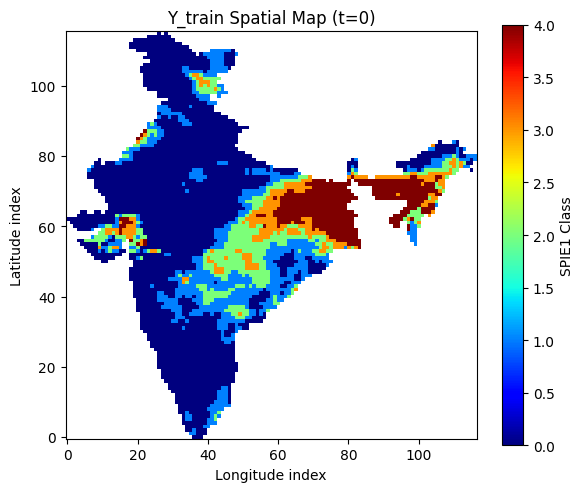

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Choose any time index
t = 0  # change this to visualize other times

# Extract spatial field (lat, lon)
spei1 = Y_train[t, 0, :, :]  # shape (32, 32)

plt.figure(figsize=(6, 5))
plt.imshow(np.flipud(spei1), origin="lower", cmap="jet")
plt.colorbar(label="SPIE1 Class")
plt.title(f"Y_train Spatial Map (t={t})")
plt.xlabel("Longitude index")
plt.ylabel("Latitude index")
plt.tight_layout()
plt.show()

# changing the data into tabular form

In [5]:
import numpy as np
import pandas as pd

def prepare_tabular_ml_dataset(
    X,
    Y,
    time_index,     # pandas.DatetimeIndex
    latitudes,      # shape (H,)
    longitudes,     # shape (W,)
):
    """
    Convert gridded climate data into tabular ML dataset
    with cyclic encodings for space and time.

    Parameters
    ----------
    X : np.ndarray
        Shape (T, C, H, W)
    Y : np.ndarray
        Shape (T, 1, H, W)
    time_index : pandas.DatetimeIndex
        Length T
    latitudes : np.ndarray
        Shape (H,)
    longitudes : np.ndarray
        Shape (W,)

    Returns
    -------
    X_tab : np.ndarray
        Shape (N, F)
    y_tab : np.ndarray
        Shape (N,)
    """

    T, C, H, W = X.shape

    # ------------------------------------------------
    # 1. Flatten predictors
    # ------------------------------------------------
    X_tab = X.transpose(0, 2, 3, 1).reshape(-1, C)

    # ------------------------------------------------
    # 2. Flatten target
    # ------------------------------------------------
    y_tab = Y[:, 0].reshape(-1)

    # ------------------------------------------------
    # 3. Spatial encodings (lat/lon → sin/cos)
    # ------------------------------------------------
    lat_rad = np.deg2rad(latitudes)
    lon_rad = np.deg2rad(longitudes)

    lat_grid, lon_grid = np.meshgrid(lat_rad, lon_rad, indexing="ij")

    sin_lat = np.sin(lat_grid).ravel()
    cos_lat = np.cos(lat_grid).ravel()
    sin_lon = np.sin(lon_grid).ravel()
    cos_lon = np.cos(lon_grid).ravel()

    # Repeat for all time steps
    sin_lat = np.tile(sin_lat, T)
    cos_lat = np.tile(cos_lat, T)
    sin_lon = np.tile(sin_lon, T)
    cos_lon = np.tile(cos_lon, T)

    # ------------------------------------------------
    # 4. Temporal encodings (Month as integer 1-12)
    # ------------------------------------------------
    # month = time_index.month.values


    # # Repeat month across spatial grid
    # month_repeated = np.repeat(month, H * W)
    month = time_index.month.values

    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)

    month_sin = np.repeat(month_sin, H * W)
    month_cos = np.repeat(month_cos, H * W)

    # ------------------------------------------------
    # 5. Concatenate all features
    # ------------------------------------------------
    X_tab = np.column_stack([
        X_tab,
        # month_repeated,
        month_sin, month_cos,
        sin_lat, cos_lat,
        sin_lon, cos_lon,
    ])

    # ------------------------------------------------
    # 6. Remove NaNs / Infs
    # ------------------------------------------------
    valid = np.isfinite(X_tab).all(axis=1) & np.isfinite(y_tab)
    X_tab = X_tab[valid]
    y_tab = y_tab[valid]

    return X_tab, y_tab


In [6]:
time_index = data.time.to_index()

Xtr, ytr = prepare_tabular_ml_dataset(
    X_train,
    Y_train,
    time_index=time_index[:len(X_train)],
    latitudes=data.lat.values,
    longitudes=data.lon.values
)

Xva, yva = prepare_tabular_ml_dataset(
    X_valid,
    Y_valid,
    time_index=time_index[len(X_train):len(X_train)+len(X_valid)],
    latitudes=data.lat.values,
    longitudes=data.lon.values
)

Xte, yte = prepare_tabular_ml_dataset(
    X_test,
    Y_test,
    time_index=time_index[-len(X_test):],
    latitudes=data.lat.values,
    longitudes=data.lon.values
)
print("Train:", Xtr.shape, ytr.shape)
print("Valid:", Xva.shape, yva.shape)
print("Test:", Xte.shape, yte.shape)

Train: (3386008, 21) (3386008,)
Valid: (1160000, 21) (1160000,)
Test: (213440, 21) (213440,)


# EDA

In [ ]:
import pandas as pd
TrainData = pd.DataFrame(Xtr, columns=['t2m_lag2', 'e_lag2', 'ro_lag2', 'tp_lag2', 'cdir_lag2',
                                       't2m_lag1', 'e_lag1', 'ro_lag1', 'tp_lag1', 'cdir_lag1', 
                                       "t2m", "e", 'ro', 'tp','cdir', 
                                       'month_sin', 'month_cos', 'sin_lat', 'cos_lat', 'sin_lon', 'cos_lon'])
TrainData['Target'] = ytr
TrainData.to_csv(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/TrainDataV3.csv', index=False)
TrainData.head()

,t2m_lag2,e_lag2,ro_lag2,tp_lag2,cdir_lag2,t2m_lag1,e_lag1,ro_lag1,tp_lag1,cdir_lag1,...,ro,tp,cdir,month_sin,month_cos,sin_lat,cos_lat,sin_lon,cos_lon,Target
0,-4.307594,1.791817,-0.375822,-0.412930,-1.962209,-4.234053,1.795440,-0.368157,-0.530591,-0.756526,...,-0.378542,-0.295815,0.820856,0.5,0.866025,0.601815,0.798636,0.964787,0.263031,0.0
1,-4.135662,1.766785,-0.375822,-0.514406,-1.972244,-4.067271,1.741769,-0.339967,-0.579874,-0.769298,...,-0.353320,-0.440754,0.802307,0.5,0.866025,0.601815,0.798636,0.967046,0.254602,0.0
2,-4.228733,1.808788,-0.380768,-0.256534,-1.955519,-4.137074,1.804774,-0.380768,-0.428024,-0.763064,...,-0.380768,-0.005573,0.790904,0.5,0.866025,0.598325,0.801254,0.961262,0.275637,0.0
3,-4.364609,1.817274,-0.380768,-0.181610,-1.946093,-4.274016,1.814532,-0.380768,-0.389834,-0.749836,...,-0.379531,-0.019394,0.808845,0.5,0.866025,0.598325,0.801254,0.962455,0.271440,0.0
4,-4.325001,1.817698,-0.380768,-0.220527,-1.935146,-4.229435,1.815169,-0.380768,-0.416931,-0.735545,...,-0.379531,-0.087954,0.829066,0.5,0.866025,0.598325,0.801254,0.963630,0.267238,0.0


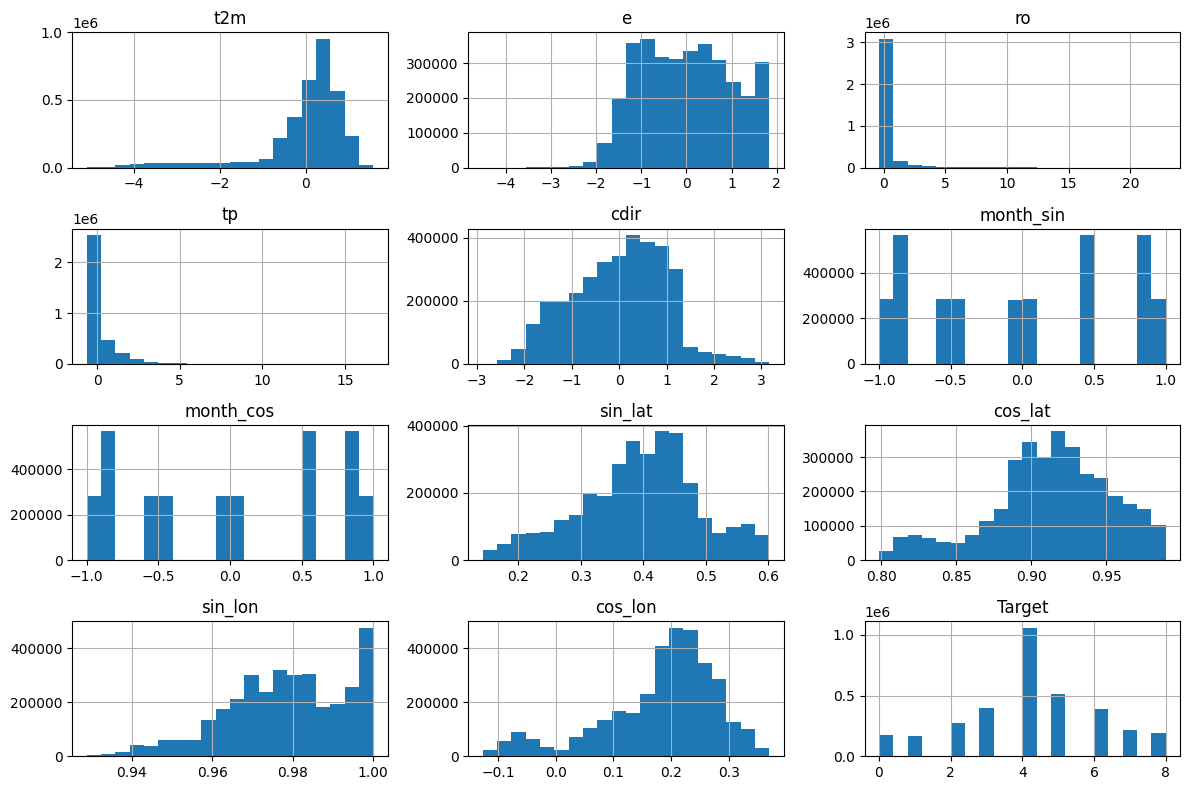

In [92]:
import matplotlib.pyplot as plt
TrainData.hist(figsize=(12, 8), bins=20)
plt.tight_layout()

In [93]:
for column in TrainData.columns:
    print(f"{column}: {TrainData[column].nunique()} unique values")

t2m: 767642 unique values
e: 1007834 unique values
ro: 26698 unique values
tp: 30078 unique values
cdir: 414635 unique values
month_sin: 11 unique values
month_cos: 11 unique values
sin_lat: 116 unique values
cos_lat: 116 unique values
sin_lon: 91 unique values
cos_lon: 117 unique values
Target: 9 unique values


In [57]:
print(len(TrainData.sin_lat.unique()))
print(len(TrainData.cos_lat.unique()))
print(len(TrainData.sin_lon.unique()))
print(len(TrainData.cos_lon.unique()))

116
116
91
117


In [7]:
# Validation data prepareation
ValidData = pd.DataFrame(Xva, columns=['t2m_lag2', 'e_lag2', 'ro_lag2', 'tp_lag2', 'cdir_lag2',
                                       't2m_lag1', 'e_lag1', 'ro_lag1', 'tp_lag1', 'cdir_lag1', 
                                       "t2m", "e", 'ro', 'tp','cdir', 
                                       'month_sin', 'month_cos', 'sin_lat', 'cos_lat', 'sin_lon', 'cos_lon'])
ValidData['Target'] = yva
ValidData.to_csv(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/ValidDataV3.csv', index=False)
ValidData.head()

,t2m_lag2,e_lag2,ro_lag2,tp_lag2,cdir_lag2,t2m_lag1,e_lag1,ro_lag1,tp_lag1,cdir_lag1,...,ro,tp,cdir,month_sin,month_cos,sin_lat,cos_lat,sin_lon,cos_lon,Target
0,-4.179373,1.797502,-0.380768,-0.487673,-2.002652,-4.327268,1.790147,-0.380768,-0.535683,-0.742842,...,-0.380768,-0.359646,0.757625,-0.5,0.866025,0.601815,0.798636,0.964787,0.263031,0.0
1,-3.985594,1.719011,-0.380768,-0.548776,-2.002652,-4.130825,1.690867,-0.380768,-0.570054,-0.753941,...,-0.362469,-0.470397,0.751544,-0.5,0.866025,0.601815,0.798636,0.967046,0.254602,0.0
2,-4.131239,1.807260,-0.361480,-0.353827,-2.009950,-4.342188,1.806693,-0.380520,-0.475489,-0.744667,...,-0.380768,-0.159969,0.717031,-0.5,0.866025,0.598325,0.801254,0.961262,0.275637,0.0
3,-4.273333,1.817867,-0.374091,-0.314910,-1.997483,-4.462789,1.816664,-0.380768,-0.456576,-0.735393,...,-0.379531,-0.127235,0.734819,-0.5,0.866025,0.598325,0.801254,0.962455,0.271440,0.0
4,-4.227863,1.816594,-0.380768,-0.342734,-1.984103,-4.405952,1.816027,-0.380768,-0.455666,-0.726270,...,-0.379531,-0.182519,0.753520,-0.5,0.866025,0.598325,0.801254,0.963630,0.267238,0.0


In [8]:
# Test data prepareation
TestData = pd.DataFrame(Xte, columns=['t2m_lag2', 'e_lag2', 'ro_lag2', 'tp_lag2', 'cdir_lag2',
                                       't2m_lag1', 'e_lag1', 'ro_lag1', 'tp_lag1', 'cdir_lag1', 
                                       "t2m", "e", 'ro', 'tp','cdir', 
                                       'month_sin', 'month_cos', 'sin_lat', 'cos_lat', 'sin_lon', 'cos_lon'])
TestData['Target'] = yte
TestData.to_csv(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/TestDataV3.csv', index=False)
TestData.head()

,t2m_lag2,e_lag2,ro_lag2,tp_lag2,cdir_lag2,t2m_lag1,e_lag1,ro_lag1,tp_lag1,cdir_lag1,...,ro,tp,cdir,month_sin,month_cos,sin_lat,cos_lat,sin_lon,cos_lon,Target
0,-4.289212,1.813545,-0.380768,-0.518770,-1.951566,-3.739773,1.767448,-0.366426,-0.332732,-0.820231,...,-0.380768,-0.234166,0.617359,1.0,6.123234e-17,0.601815,0.798636,0.964787,0.263031,0.0
1,-4.048542,1.787240,-0.380273,-0.546049,-1.962057,-3.552209,1.668168,-0.380768,-0.417658,-0.825857,...,-0.380768,-0.388198,0.629522,1.0,6.123234e-17,0.601815,0.798636,0.967046,0.254602,0.0
2,-4.257419,1.815666,-0.367909,-0.482035,-1.941075,-3.701763,1.789935,-0.380768,-0.145057,-0.841213,...,-0.380768,0.105541,0.549397,1.0,6.123234e-17,0.598325,0.801254,0.961262,0.275637,0.0
3,-4.343208,1.819484,-0.376317,-0.441663,-1.934082,-3.884708,1.812421,-0.380768,-0.020485,-0.827985,...,-0.377800,0.175919,0.567186,1.0,6.123234e-17,0.598325,0.801254,0.962455,0.271440,0.0
4,-4.332551,1.819060,-0.380768,-0.436571,-1.926480,-3.829469,1.808602,-0.380768,-0.085408,-0.813085,...,-0.379284,0.066078,0.588015,1.0,6.123234e-17,0.598325,0.801254,0.963630,0.267238,0.0


# Model Selection

In [11]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from ngboost import NGBClassifier
# from ngboost.distns import k_NaturalGradient  # k_NaturalGradient is often used for multiclass
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [22]:
models = {
    "XGBoost": XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    tree_method='hist',
    device='cuda',
    eval_metric='mlogloss'
    )
    # "LogisticRegression": LogisticRegression(max_iter=1000),
    # # "RidgeClassifier": RidgeClassifier(),
    # "RandomForest": RandomForestClassifier(),
    # # "ExtraTrees": ExtraTreesClassifier(),
    # # "AdaBoost": AdaBoostClassifier(),
    # # "HistGradientBoosting": HistGradientBoostingClassifier(),
    # "XGBoost": XGBClassifier(
    #     use_label_encoder=False, 
    #     eval_metric='mlogloss',
    #     tree_method='hist',  # GPU acceleration
    #     device='cuda'  # GPU device
    # ),
    # "LightGBM": LGBMClassifier(device='gpu'),  # GPU acceleration
    # "CatBoost": CatBoostClassifier(
    #     verbose=0,
    #     task_type='GPU'  # GPU acceleration
    # ),
    # "NGBoost": NGBClassifier(),
    # "SVM": SVC(probability=True),  # probability=True allows you to see confidence scores
    # "KNN": KNeighborsClassifier(n_neighbors=9) # Starting with k=9 is a common rule of thumb for 9 classes
}

In [23]:
from sklearn.metrics import accuracy_score, f1_score

# Dictionary to store results for comparison
results = {}

print("=" * 70)
print("GPU-ENABLED MODELS: XGBoost, LightGBM, CatBoost")
print("CPU-ONLY MODELS: LogisticRegression, RandomForest, NGBoost, SVM, KNN")
print("=" * 70)
print(f"{'Model Name':<25} | {'Val Accuracy':<15} | {'Val F1 (Macro)':<15}")
print("-" * 60)

for name, model in models.items():
    try:
        # 1. Train on training data
        model.fit(Xtr, ytr)
        
        # 2. Predict on validation data
        val_preds = model.predict(Xva)
        
        # 3. Calculate Metrics
        # Using 'macro' F1 because you have 9 classes; it treats all classes equally
        val_acc = accuracy_score(yva, val_preds)
        val_f1 = f1_score(yva, val_preds, average='macro')
        
        results[name] = {"acc": val_acc, "f1": val_f1}
        
        print(f"{name:<25} | {val_acc:<15.4f} | {val_f1:<15.4f}")
        
    except Exception as e:
        print(f"Could not train {name}: {e}")

# --- Final Step: Test the Winner ---
best_model_name = max(results, key=lambda x: results[x]['f1'])
print(f"\n🏆 Best Model based on Validation F1: {best_model_name}")


GPU-ENABLED MODELS: XGBoost, LightGBM, CatBoost
CPU-ONLY MODELS: LogisticRegression, RandomForest, NGBoost, SVM, KNN
Model Name                | Val Accuracy    | Val F1 (Macro) 
------------------------------------------------------------
XGBoost                   | 0.7492          | 0.4674         

🏆 Best Model based on Validation F1: XGBoost


In [14]:

# Now evaluate the winner on the actual Test Set (yte)
final_preds = models[best_model_name].predict(Xte)
test_acc = accuracy_score(yte, final_preds)

print(f"Final Accuracy on Test Set: {test_acc:.4f}")

Final Accuracy on Test Set: 0.7723
